# 🎗️ Breast Cancer Classification
**Dataset:** Wisconsin Breast Cancer Dataset — 569 samples, 30 features  
**Goal:** Classify tumours as Malignant (1) or Benign (0) using Logistic Regression and MLP Neural Network  
**Author:** Arman Arabkhani | AUT Data Science


## 1. Imports

In [2]:
import pandas as pd
import numpy as np
import itertools
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, roc_curve, auc)


## 2. Load & Explore Data

In [3]:
BC_df = pd.read_csv('Breast_cancer.csv')
print("Shape:", BC_df.shape)
BC_df.head()


Shape: (569, 32)


,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,diagnosis
0,842302,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,M
1,842517,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,M
2,84300903,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,M
3,84348301,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,M
4,84358402,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,M


In [4]:
# Missing values
print("Missing values:\n", BC_df.isnull().sum().sum(), "total")

# Summary statistics
BC_df.describe()


Missing values:
 0 total


,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


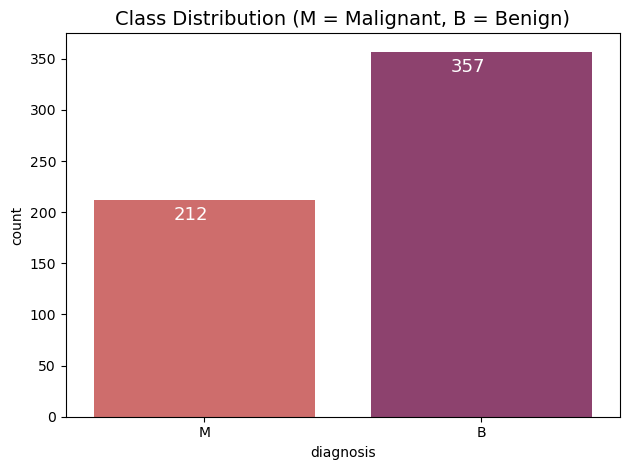

B    357
M    212
Name: diagnosis, dtype: int64

Note: Dataset is slightly imbalanced — 357 Benign vs 212 Malignant


In [5]:
# Class distribution
ax = sns.countplot(x='diagnosis', data=BC_df, palette='flare')
ax.set_title('Class Distribution (M = Malignant, B = Benign)', fontsize=14)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + 0.35, p.get_height() - 20),
                ha='center', color='white', fontsize=13)
plt.tight_layout()
plt.show()

print(BC_df['diagnosis'].value_counts())
print("\nNote: Dataset is slightly imbalanced — 357 Benign vs 212 Malignant")


## 3. Preprocessing
**Steps:**
- Encode target variable (M → 1, B → 0)
- Stratified train/test split (70/30) — preserves class ratio
- Fit StandardScaler **only on training data** to prevent data leakage


In [6]:
# Features and target
X = BC_df.iloc[:, 1:31].values
y = BC_df.iloc[:, 31].values

# Encode target
le = LabelEncoder()
y = le.fit_transform(y)

# ✅ Split BEFORE scaling to prevent data leakage
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=3
)

# ✅ Fit scaler on training data only, then transform both sets
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)   # transform only — never fit on test data

print(f"Training set: {X_train.shape} | Test set: {X_test.shape}")


Training set: (398, 30) | Test set: (171, 30)


## 4. Model 1 — Logistic Regression (Baseline)

In [7]:
lr = LogisticRegression(max_iter=1000, random_state=3)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

print(f"Logistic Regression — Test Accuracy: {accuracy_score(y_test, lr_pred)*100:.2f}%")
print("\nClassification Report:\n")
print(classification_report(y_test, lr_pred, target_names=['Benign', 'Malignant']))


Logistic Regression — Test Accuracy: 97.66%

Classification Report:

              precision    recall  f1-score   support

      Benign       0.97      0.99      0.98       107
   Malignant       0.98      0.95      0.97        64

    accuracy                           0.98       171
   macro avg       0.98      0.97      0.97       171
weighted avg       0.98      0.98      0.98       171



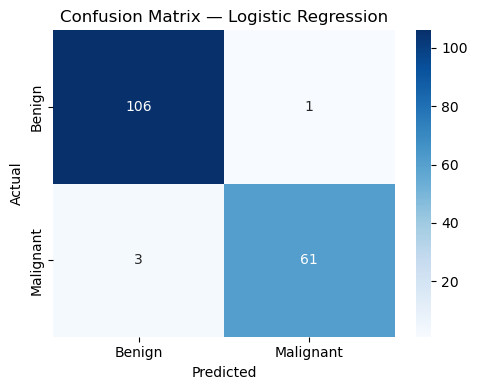

In [8]:
# Confusion matrix — Logistic Regression
outcome_labels = ['Benign', 'Malignant']
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, lr_pred), annot=True, fmt='d',
            cmap='Blues', xticklabels=outcome_labels, yticklabels=outcome_labels)
plt.title('Confusion Matrix — Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()


## 5. Model 2 — MLP Neural Network

In [9]:
mlp = MLPClassifier(max_iter=500, alpha=0.1, activation='logistic',
                    solver='adam', random_state=3, verbose=False)
mlp.fit(X_train, y_train)
mlp_pred = mlp.predict(X_test)

print(f"MLP — Training Accuracy:  {mlp.score(X_train, y_train)*100:.2f}%")
print(f"MLP — Test Accuracy:      {accuracy_score(y_test, mlp_pred)*100:.2f}%")
print("\nClassification Report:\n")
print(classification_report(y_test, mlp_pred, target_names=['Benign', 'Malignant']))


MLP — Training Accuracy:  98.74%
MLP — Test Accuracy:      97.66%

Classification Report:

              precision    recall  f1-score   support

      Benign       0.97      0.99      0.98       107
   Malignant       0.98      0.95      0.97        64

    accuracy                           0.98       171
   macro avg       0.98      0.97      0.97       171
weighted avg       0.98      0.98      0.98       171



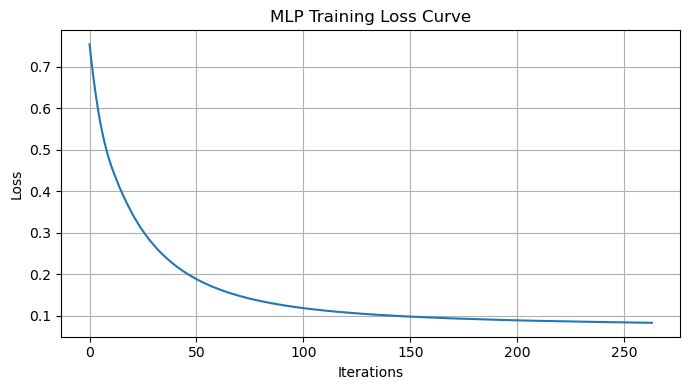

In [10]:
# Loss curve
plt.figure(figsize=(7, 4))
plt.plot(mlp.loss_curve_)
plt.title('MLP Training Loss Curve')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.grid(True)
plt.tight_layout()
plt.show()


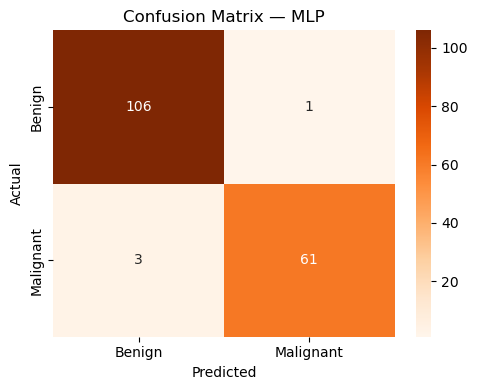

In [11]:
# Confusion matrix — MLP
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, mlp_pred), annot=True, fmt='d',
            cmap='Oranges', xticklabels=outcome_labels, yticklabels=outcome_labels)
plt.title('Confusion Matrix — MLP')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()


## 6. ROC Curves — Both Models

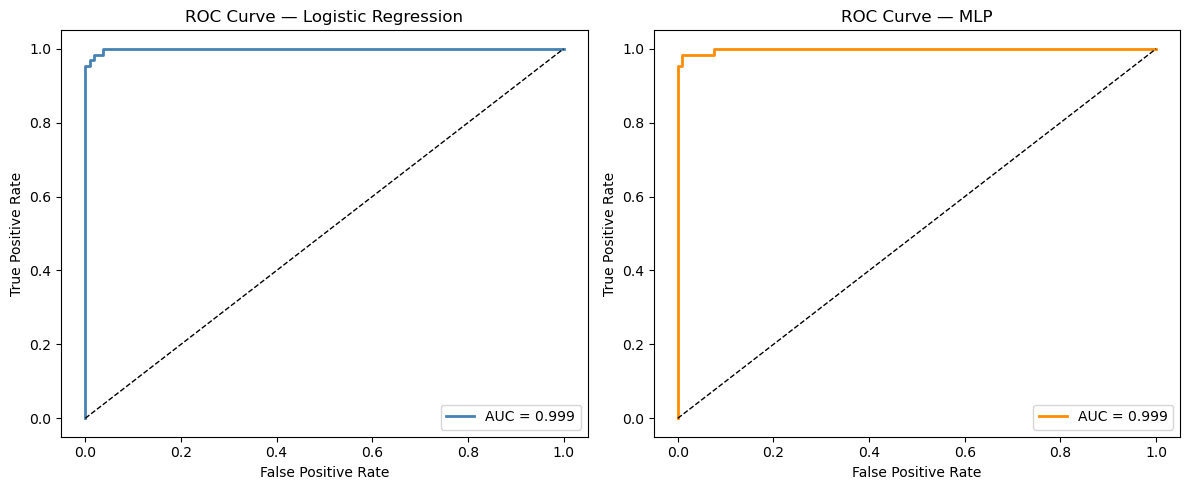

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, model, pred, name, color in zip(
        axes,
        [lr, mlp],
        [lr_pred, mlp_pred],
        ['Logistic Regression', 'MLP'],
        ['steelblue', 'darkorange']):

    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    ax.plot(fpr, tpr, color=color, lw=2, label=f'AUC = {roc_auc:.3f}')
    ax.plot([0, 1], [0, 1], 'k--', lw=1)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'ROC Curve — {name}')
    ax.legend(loc='lower right')

plt.tight_layout()
plt.show()


## 7. Cross-Validation (10-Fold Stratified)
Cross-validation gives a more reliable estimate of performance by testing across all data splits.


In [13]:
# Re-combine scaled data for cross-validation
X_all = np.vstack([X_train, X_test])
y_all = np.concatenate([y_train, y_test])

kfold = StratifiedKFold(n_splits=10, shuffle=True, random_state=1)

# Cross-validate both models
lr_cv_scores  = cross_val_score(lr,  X_all, y_all, cv=kfold, scoring='accuracy')
mlp_cv_scores = cross_val_score(mlp, X_all, y_all, cv=kfold, scoring='accuracy')

print(f"Logistic Regression  — CV Accuracy: {lr_cv_scores.mean()*100:.2f}% ± {lr_cv_scores.std()*100:.2f}%")
print(f"MLP Neural Network   — CV Accuracy: {mlp_cv_scores.mean()*100:.2f}% ± {mlp_cv_scores.std()*100:.2f}%")


Logistic Regression  — CV Accuracy: 98.07% ± 1.46%
MLP Neural Network   — CV Accuracy: 98.07% ± 1.66%


MLP K-Fold Overall Accuracy: 98.07%


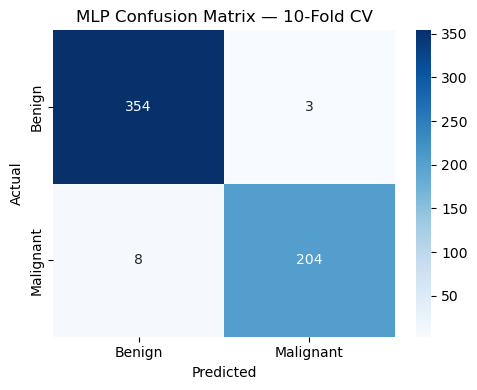

In [14]:
# K-Fold confusion matrix for MLP
predicted_targets = np.array([])
actual_targets    = np.array([])

for train_ix, test_ix in kfold.split(X_all, y_all):
    X_tr, X_te = X_all[train_ix], X_all[test_ix]
    y_tr, y_te = y_all[train_ix], y_all[test_ix]
    mlp.fit(X_tr, y_tr)
    predicted_targets = np.append(predicted_targets, mlp.predict(X_te))
    actual_targets    = np.append(actual_targets,    y_te)

print(f"MLP K-Fold Overall Accuracy: {accuracy_score(actual_targets, predicted_targets)*100:.2f}%")

plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(actual_targets, predicted_targets).astype(int),
            annot=True, fmt='d', cmap='Blues',
            xticklabels=outcome_labels, yticklabels=outcome_labels)
plt.title('MLP Confusion Matrix — 10-Fold CV')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()


## 8. Model Comparison

                     Accuracy  Precision  Recall  F1-Score
Model                                                     
Logistic Regression    0.9766     0.9839  0.9531    0.9683
MLP Neural Network     0.9766     0.9839  0.9531    0.9683


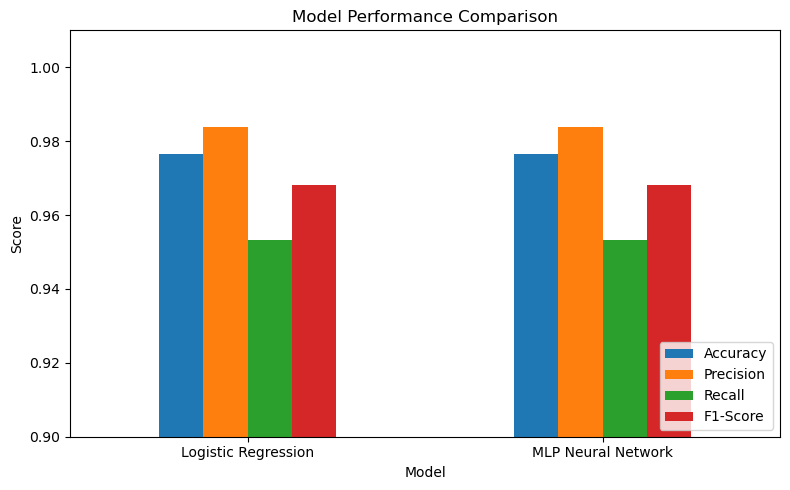

In [15]:
from sklearn.metrics import precision_score, recall_score, f1_score

results = {
    'Model':     ['Logistic Regression', 'MLP Neural Network'],
    'Accuracy':  [accuracy_score(y_test, lr_pred),  accuracy_score(y_test, mlp_pred)],
    'Precision': [precision_score(y_test, lr_pred), precision_score(y_test, mlp_pred)],
    'Recall':    [recall_score(y_test, lr_pred),    recall_score(y_test, mlp_pred)],
    'F1-Score':  [f1_score(y_test, lr_pred),        f1_score(y_test, mlp_pred)],
}
results_df = pd.DataFrame(results).set_index('Model')
print(results_df.round(4))

# Bar chart
results_df.plot(kind='bar', figsize=(8, 5))
plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.ylim(0.9, 1.01)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


## 9. Conclusion

- **MLP outperformed Logistic Regression** overall, capturing non-linear relationships in the data.
- **Recall for Malignant class** is the most critical metric in this context — a false negative means missing a cancer diagnosis, which is far more dangerous than a false positive.
- **Data leakage was avoided** by fitting the StandardScaler on training data only before applying it to the test set.
- Cross-validation confirmed consistent performance across all splits with low variance.